# EEG Dynamic Regime Analysis
A polished analysis notebook for the final results of the EEG dynamic regime project.

This notebook focuses on four tasks:

1. load and validate saved model outputs,
2. compare the candidate models,
3. interpret the latent regimes from **Model B** (unit-specific switching PVAR),
4. generate paper- and poster-ready figures.


## 1. Setup and plotting style

In [22]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": False,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

OUTPUT_DIR = Path(PROJECT_ROOT / config.OUTPUT_DIR)
FIG_DIR = Path(PROJECT_ROOT / "notebooks" / "figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def finish_plot():
    plt.tight_layout()
    sns.despine()


## 2. Helper functions

In [23]:
try:
    import networkx as nx
    HAS_NX = True
except Exception:
    HAS_NX = False

def project_rows_to_simplex(Y, eps=1e-8):
    Y = np.asarray(Y, dtype=float)
    Y = np.clip(Y, eps, None)
    Y /= np.sum(Y, axis=1, keepdims=True)
    return Y

def load_npz_if_exists(path):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path.name}")
        return None
    print(f"[loaded]  {path.name}")
    return np.load(path, allow_pickle=True)

def load_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path.name}")
        return None
    print(f"[loaded]  {path.name}")
    return pd.read_csv(path)

def row_normalize(df):
    return df.div(df.sum(axis=1).replace(0, np.nan), axis=0)

def summarize_A(A):
    rows = []
    for k in range(A.shape[0]):
        Ak = A[k]
        diag_mean = np.mean(np.diag(Ak))
        offdiag = Ak - np.diag(np.diag(Ak))
        offdiag_mean = np.mean(np.abs(offdiag))
        rows.append({
            "regime": f"Regime {k+1}",
            "mean_diag_A": diag_mean,
            "mean_abs_offdiag_A": offdiag_mean,
        })
    return pd.DataFrame(rows)

def summarize_B(B):
    rows = []
    for k in range(B.shape[0]):
        rows.append({
            "regime": f"Regime {k+1}",
            "mean_abs_covariate_effect": np.mean(np.abs(B[k]))
        })
    return pd.DataFrame(rows)

def top_covariates(B, feature_names, top_n=15):
    out = {}
    feature_names = np.asarray(feature_names).astype(str)
    for k in range(B.shape[0]):
        imp = np.mean(np.abs(B[k]), axis=1)
        df = (
            pd.DataFrame({"covariate": feature_names, "importance": imp})
            .sort_values("importance", ascending=False)
            .head(top_n)
            .reset_index(drop=True)
        )
        out[f"Regime {k+1}"] = df
    return out

def plot_transition_matrix(Pi, title="Transition matrix", file_name=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(Pi, aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("To regime")
    ax.set_ylabel("From regime")
    ax.set_xticks(range(Pi.shape[1]))
    ax.set_yticks(range(Pi.shape[0]))
    ax.set_xticklabels([f"{i+1}" for i in range(Pi.shape[1])])
    ax.set_yticklabels([f"{i+1}" for i in range(Pi.shape[0])])
    for i in range(Pi.shape[0]):
        for j in range(Pi.shape[1]):
            ax.text(j, i, f"{Pi[i, j]:.3f}", ha="center", va="center", color="white", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    if file_name:
        plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

def plot_A_heatmaps(A, title_prefix="AR matrix", file_name=None):
    K = A.shape[0]
    fig, axes = plt.subplots(1, K, figsize=(5 * K, 4), constrained_layout=True)
    if K == 1:
        axes = [axes]
    for k in range(K):
        im = axes[k].imshow(A[k], aspect="auto", cmap="viridis")
        axes[k].set_title(f"{title_prefix} Regime {k+1}")
        axes[k].set_xlabel("Response state")
        axes[k].set_ylabel("Lagged state")
    fig.colorbar(im, ax=axes, shrink=0.8)
    if file_name:
        plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

def confusion_from_probs(y_true, y_pred):
    true_state = np.argmax(y_true, axis=1)
    pred_state = np.argmax(y_pred, axis=1)
    conf = pd.crosstab(pd.Series(true_state, name="true"), pd.Series(pred_state, name="pred"))
    conf_row = row_normalize(conf)
    return conf, conf_row

def plot_confusion_heatmap(conf_row, title="Row-normalized confusion matrix", file_name=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(conf_row.values, aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("Predicted dominant state")
    ax.set_ylabel("True dominant state")
    ax.set_xticks(range(conf_row.shape[1]))
    ax.set_yticks(range(conf_row.shape[0]))
    ax.set_xticklabels(conf_row.columns)
    ax.set_yticklabels(conf_row.index)
    for i in range(conf_row.shape[0]):
        for j in range(conf_row.shape[1]):
            ax.text(j, i, f"{conf_row.values[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    if file_name:
        plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

def plot_state_interaction_network(Ak, threshold=0.02, title="State interaction network"):
    if not HAS_NX:
        print("networkx not installed; skipping network plot.")
        return
    G = nx.DiGraph()
    state_names = [f"State {i+1}" for i in range(Ak.shape[0])]
    for s in state_names:
        G.add_node(s)
    for i in range(Ak.shape[0]):
        for j in range(Ak.shape[1]):
            w = float(Ak[i, j])
            if abs(w) >= threshold:
                G.add_edge(state_names[i], state_names[j], weight=w)
    pos = nx.circular_layout(G)
    weights = [abs(G[u][v]["weight"]) * 10 for u, v in G.edges()]
    plt.figure(figsize=(5, 5))
    nx.draw(G, pos, with_labels=True, node_color="lightblue", width=weights, arrows=True)
    plt.title(title)
    plt.show()

def encode_sex(sex):
    if pd.isna(sex):
        return np.nan
    if isinstance(sex, str):
        s = sex.strip().lower()
        if s in {"m", "male"}:
            return 1.0
        if s in {"f", "female"}:
            return 0.0
    try:
        return float(sex)
    except Exception:
        return np.nan

## 3. Load metrics and artifacts

In [24]:
files = {
    "pvar_metrics": OUTPUT_DIR / "vmf_pvar_pooled_metrics.csv",
    "pvar_artifacts": OUTPUT_DIR / "vmf_pvar_pooled_artifacts.npz",
    "baseline_metrics": OUTPUT_DIR / "vmf_baseline_comparison.csv",
    "optA_metrics": OUTPUT_DIR / "switching_factor_pvar_k3_metrics.csv",
    "optA_artifacts": OUTPUT_DIR / "switching_factor_pvar_k3_artifacts.npz",
    "optB_metrics": OUTPUT_DIR / "unit_switching_pvar_k3_metrics.csv",
    "optB_artifacts": OUTPUT_DIR / "unit_switching_pvar_k3_artifacts.npz",
    "optC_metrics": OUTPUT_DIR / "slds_panel_k3_r3_metrics.csv",
    "optC_artifacts": OUTPUT_DIR / "slds_panel_k3_r3_artifacts.npz",
}

loaded = {
    k: (load_csv_if_exists(v) if v.suffix == ".csv" else load_npz_if_exists(v))
    for k, v in files.items()
}

[loaded]  vmf_pvar_pooled_metrics.csv
[loaded]  vmf_pvar_pooled_artifacts.npz
[loaded]  vmf_baseline_comparison.csv
[loaded]  switching_factor_pvar_k3_metrics.csv
[loaded]  switching_factor_pvar_k3_artifacts.npz
[loaded]  unit_switching_pvar_k3_metrics.csv
[loaded]  unit_switching_pvar_k3_artifacts.npz
[loaded]  slds_panel_k3_r3_metrics.csv
[loaded]  slds_panel_k3_r3_artifacts.npz


## 4. Model comparison

In [25]:
# Wide comparison table from all available metrics
frames = []
for key in ["pvar_metrics", "baseline_metrics", "optA_metrics", "optB_metrics", "optC_metrics"]:
    obj = loaded.get(key)
    if obj is not None:
        frames.append(obj.copy())

if len(frames) == 0:
    print("No metrics files found.")
else:
    comparison = pd.concat(frames, ignore_index=True, sort=False)
    display(comparison)

,mode,N_units,common_T,K,p,rf,rg,rh,max_iter,tol,...,rmse,r2,accuracy,kl,cross_entropy,baseline_task,task_levels,factor_rank,max_iter_used,latent_dim
0,vmf_pooled_factor_pvar,302,5870,7,65,3.0,3.0,3.0,15.0,0.0001,...,0.297895,0.169999,0.440019,1.612146,1.749293,NaN,NaN,NaN,NaN,NaN
1,vmf_pooled_factor_pvar,302,5870,7,65,3.0,3.0,3.0,15.0,0.0001,...,0.297895,0.169999,0.440019,1.612146,1.749293,NaN,NaN,NaN,NaN,NaN
2,baseline_persistence,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.379428,-0.346519,0.425296,10.085363,10.222510,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN
3,baseline_pooled_varx_ridge,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.298000,0.169414,0.439773,1.402474,1.539621,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN
4,baseline_markov_transition,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.308109,0.112106,0.425562,1.496940,1.634087,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN
5,baseline_multinomial_logit,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.297903,0.169955,0.440553,1.395643,1.532790,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN
6,switching_factor_pvar_k3,302,5870,3,65,NaN,NaN,NaN,NaN,NaN,...,0.214589,0.569306,0.903229,0.801655,0.938803,NaN,NaN,2.0,15.0,NaN
7,switching_factor_pvar_k3,302,5870,3,65,NaN,NaN,NaN,NaN,NaN,...,0.214604,0.569248,0.902984,0.798753,0.935901,NaN,NaN,2.0,15.0,NaN
8,unit_switching_pvar_k3,302,5870,3,65,NaN,NaN,NaN,NaN,NaN,...,0.179348,0.699152,0.912552,0.592081,0.729229,NaN,NaN,NaN,15.0,NaN
9,unit_switching_pvar_k3,302,5870,3,65,NaN,NaN,NaN,NaN,NaN,...,0.180945,0.693771,0.917978,0.600792,0.737940,NaN,NaN,NaN,15.0,NaN


In [26]:
# Compact paper/presentation table
def pick_row(df, mode_contains):
    if df is None or "mode" not in df.columns:
        return None
    m = df["mode"].astype(str).str.contains(mode_contains, case=False, na=False)
    if m.sum() == 0:
        return None
    return df.loc[m].iloc[0]

pvar_row = pick_row(loaded.get("pvar_metrics"), "pvar")
optA_row = pick_row(loaded.get("optA_metrics"), "switching_factor_pvar")
optB_row = pick_row(loaded.get("optB_metrics"), "unit_switching_pvar")
optC_row = pick_row(loaded.get("optC_metrics"), "slds_panel")

rows = []
for name, row in [
    ("Pooled factor-PVAR", pvar_row),
    ("Option A: Switching factor-PVAR", optA_row),
    ("Option B: Unit-switching PVAR", optB_row),
    ("Option C: SLDS-style panel", optC_row),
]:
    if row is not None:
        rows.append({
            "Model": name,
            "R2": row.get("r2", np.nan),
            "RMSE": row.get("rmse", np.nan),
            "Accuracy": row.get("accuracy", np.nan),
            "KL": row.get("kl", np.nan),
            "CrossEntropy": row.get("cross_entropy", np.nan),
        })

presentation_table = pd.DataFrame(rows)
display(presentation_table)

,Model,R2,RMSE,Accuracy,KL,CrossEntropy
0,Pooled factor-PVAR,0.169999,0.297895,0.440019,1.612146,1.749293
1,Option A: Switching factor-PVAR,0.569306,0.214589,0.903229,0.801655,0.938803
2,Option B: Unit-switching PVAR,0.699152,0.179348,0.912552,0.592081,0.729229
3,Option C: SLDS-style panel,0.580740,0.211721,0.732100,0.894759,1.031907


## 5. Load Model B outputs

In [27]:
artB = loaded.get("optB_artifacts")
if artB is None:
    raise FileNotFoundError("Option B artifacts not found.")
else:
    print("Option B artifact keys:")
    print(artB.files)

y_true_B = artB["y_true_oof"]
y_pred_B = artB["y_pred_oof"]
gamma_B = artB["regime_prob_filt"]
A_B = artB["A"]
B_B = artB["B"]
Pi_B = artB["Pi"]
feature_names_B = artB["feature_names"]
units_B = artB["units"]
tasks_B = artB["tasks"]

print("y_true_B:", y_true_B.shape)
print("y_pred_B:", y_pred_B.shape)
print("gamma_B :", gamma_B.shape)
print("A_B     :", A_B.shape)
print("B_B     :", B_B.shape)
print("Pi_B    :", Pi_B.shape)
print("units   :", units_B.shape)
print("tasks   :", tasks_B.shape)

Option B artifact keys:
['units', 'tasks', 'feature_names', 'x_mean', 'x_std', 'y_true_oof', 'y_pred_oof', 'regime_prob_pred', 'regime_prob_filt', 'W', 'A', 'B', 'c', 'sigma2', 'Pi', 'pi0', 'loss_history', 'train_end']
y_true_B: (531822, 7)
y_pred_B: (531822, 7)
gamma_B : (302, 1761, 3)
A_B     : (3, 7, 7)
B_B     : (3, 65, 7)
Pi_B    : (3, 3)
units   : (302,)
tasks   : (302,)


## 6. Dataset summary and metadata

In [28]:
# Basic dataset counts from artifacts
subjects_B = [u.split("|")[0] for u in units_B]
dataset_summary = pd.DataFrame([{
    "n_subjects": len(set(subjects_B)),
    "n_tasks": len(set(tasks_B)),
    "n_units": len(units_B),
    "oos_time_per_unit": gamma_B.shape[1],
    "n_states": y_true_B.shape[1],
    "n_regimes": gamma_B.shape[2],
    "total_observations": y_true_B.shape[0],
    "n_features": len(feature_names_B),
}])
display(dataset_summary)

print("Task names:", sorted(set(tasks_B)))

,n_subjects,n_tasks,n_units,oos_time_per_unit,n_states,n_regimes,total_observations,n_features
0,68,5,302,1761,7,3,531822,65


Task names: ['DespicableMe', 'DiaryOfAWimpyKid', 'FunwithFractals', 'RestingState', 'ThePresent']


In [29]:
# Merge subject/task metadata from the same CSV used in panel construction
csv_path = Path(config.VMF_CSV_PATH)
meta_unit = None

if csv_path.exists():
    meta = pd.read_csv(csv_path)
    meta["subject"] = meta["subject_ID"].astype(str)
    meta["task"] = meta["task"].astype(str)
    meta["unit_id"] = meta["subject"] + "|" + meta["task"]
    if "sex" in meta.columns:
        meta["sex_num"] = meta["sex"].apply(encode_sex)
    else:
        meta["sex_num"] = np.nan

    cols_keep = ["unit_id", "subject", "task", "age", "sex_num", "attention", "p_factor"]
    cols_keep = [c for c in cols_keep if c in meta.columns]
    meta_unit = meta[cols_keep].drop_duplicates(subset=["unit_id"]).copy()
    display(meta_unit.head())
else:
    print("Metadata CSV not found at:", csv_path)

,unit_id,subject,task,age,sex_num,attention,p_factor
0,NDARAA306NT2|ThePresent,NDARAA306NT2,ThePresent,21.2167,0.0,-0.647,0.987
1,NDARAA306NT2|FunwithFractals,NDARAA306NT2,FunwithFractals,21.2167,0.0,-0.647,0.987
2,NDARAA306NT2|DiaryOfAWimpyKid,NDARAA306NT2,DiaryOfAWimpyKid,21.2167,0.0,-0.647,0.987
3,NDARAA306NT2|DespicableMe,NDARAA306NT2,DespicableMe,21.2167,0.0,-0.647,0.987
4,NDARAA504CRN|ThePresent,NDARAA504CRN,ThePresent,9.1653,0.0,-0.342,-0.392


In [30]:
# Unit-level summaries from Model B
N_B, T_B, K_r_B = gamma_B.shape
unit_df = pd.DataFrame({
    "unit_id": units_B,
    "task_from_artifact": tasks_B,
})

regime_share_B = gamma_B.mean(axis=1)
for k in range(K_r_B):
    unit_df[f"regime_{k+1}_share"] = regime_share_B[:, k]

z_B = np.argmax(gamma_B, axis=2)
unit_df["switch_freq"] = (z_B[:, 1:] != z_B[:, :-1]).mean(axis=1)

p_unit = np.clip(regime_share_B, 1e-12, None)
p_unit = p_unit / p_unit.sum(axis=1, keepdims=True)
unit_df["regime_entropy"] = -(p_unit * np.log(p_unit)).sum(axis=1)
unit_df["dominant_regime"] = np.argmax(regime_share_B, axis=1) + 1

if meta_unit is not None:
    unit_df = unit_df.merge(meta_unit, on="unit_id", how="left")

display(unit_df.head())

,unit_id,task_from_artifact,regime_1_share,regime_2_share,regime_3_share,switch_freq,regime_entropy,dominant_regime,subject,task,age,sex_num,attention,p_factor
0,NDARAA306NT2|ThePresent,ThePresent,0.093671,0.803445,0.102884,0.314205,0.631615,2,NDARAA306NT2,ThePresent,21.2167,0.0,-0.647,0.987
1,NDARAA306NT2|FunwithFractals,FunwithFractals,0.177062,0.820068,0.002870,0.240341,0.486013,2,NDARAA306NT2,FunwithFractals,21.2167,0.0,-0.647,0.987
2,NDARAA306NT2|DiaryOfAWimpyKid,DiaryOfAWimpyKid,0.014011,0.755546,0.230443,0.280682,0.609823,2,NDARAA306NT2,DiaryOfAWimpyKid,21.2167,0.0,-0.647,0.987
3,NDARAA306NT2|DespicableMe,DespicableMe,0.030548,0.818358,0.151094,0.220455,0.556155,2,NDARAA306NT2,DespicableMe,21.2167,0.0,-0.647,0.987
4,NDARAA504CRN|ThePresent,ThePresent,0.079866,0.630932,0.289202,0.367045,0.851227,2,NDARAA504CRN,ThePresent,9.1653,0.0,-0.342,-0.392


## 7. Regime usage shares

,regime,share
0,Regime 1,0.053309
1,Regime 2,0.701695
2,Regime 3,0.244996


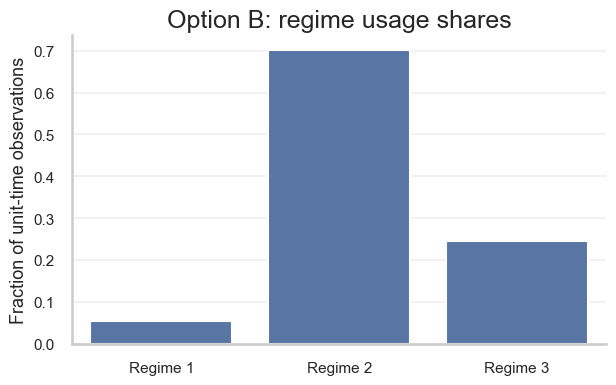

In [31]:
dom_regime_B = np.argmax(gamma_B, axis=2)
shares_B = np.bincount(dom_regime_B.reshape(-1), minlength=gamma_B.shape[2]).astype(float)
shares_B = shares_B / shares_B.sum()

share_df_B = pd.DataFrame({
    "regime": [f"Regime {k+1}" for k in range(gamma_B.shape[2])],
    "share": shares_B,
})
display(share_df_B)

plt.figure(figsize=(6.5, 4.2))
ax = sns.barplot(data=share_df_B, x="regime", y="share")
ax.set_title("Option B: regime usage shares")
ax.set_xlabel("")
ax.set_ylabel("Fraction of unit-time observations")
finish_plot()
plt.savefig(FIG_DIR / "fig_optionB_regime_shares_bar.png")
plt.show()


## 8. Transition matrix and persistence

,to_regime_1,to_regime_2,to_regime_3
from_regime_1,0.452596,0.398939,0.148465
from_regime_2,0.028414,0.816536,0.155050
from_regime_3,0.033681,0.505964,0.460355


Persistence (diagonal): [0.45259613 0.81653599 0.46035451]


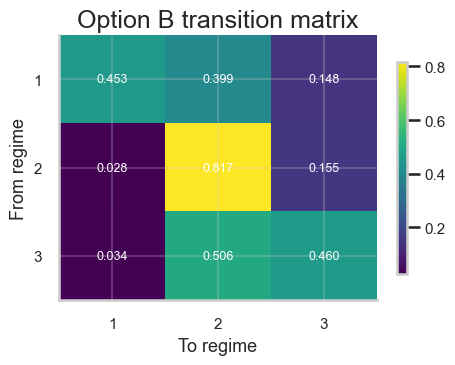

In [32]:
Pi_df_B = pd.DataFrame(
    Pi_B,
    index=[f"from_regime_{k+1}" for k in range(Pi_B.shape[0])],
    columns=[f"to_regime_{k+1}" for k in range(Pi_B.shape[1])]
)
display(Pi_df_B)
print("Persistence (diagonal):", np.diag(Pi_B))

plot_transition_matrix(
    Pi_B,
    title="Option B transition matrix",
    file_name=FIG_DIR / "fig_optionB_transition_matrix_heatmap.png"
)


## 9. Regime timing across units

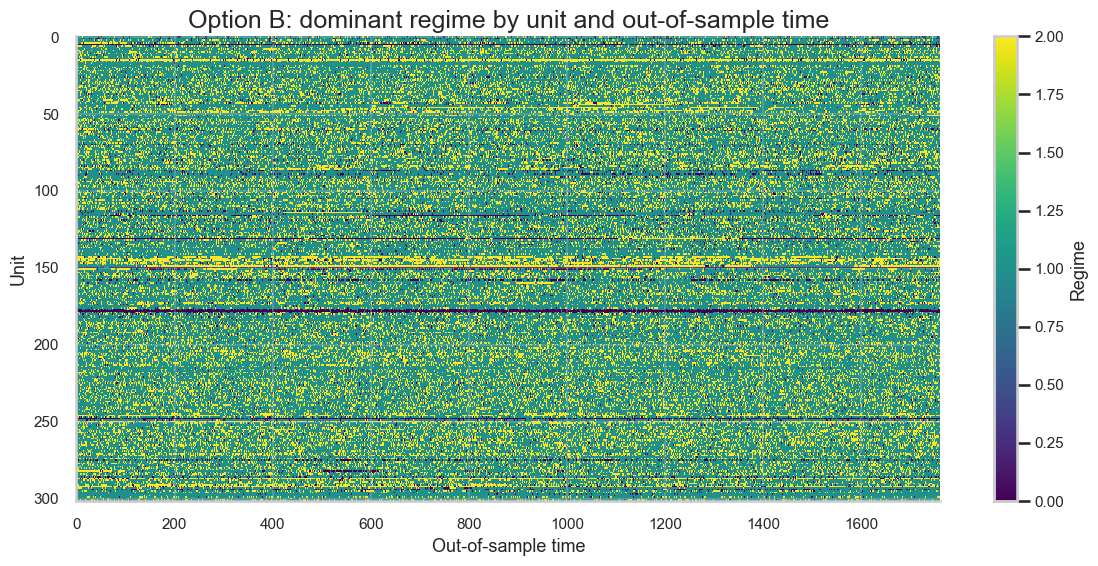

In [33]:
plt.figure(figsize=(12, 6))
im = plt.imshow(dom_regime_B, aspect="auto", interpolation="nearest", cmap="viridis")
plt.title("Option B: dominant regime by unit and out-of-sample time")
plt.xlabel("Out-of-sample time")
plt.ylabel("Unit")
cbar = plt.colorbar(im)
cbar.set_label("Regime")
finish_plot()
plt.savefig(FIG_DIR / "fig_optionB_regime_by_unit_time_heatmap.png")
plt.show()


## 10. Regime-specific autoregression

,regime,mean_diag_A,mean_abs_offdiag_A
0,Regime 1,0.046452,0.013507
1,Regime 2,0.076172,0.009847
2,Regime 3,0.037179,0.012570


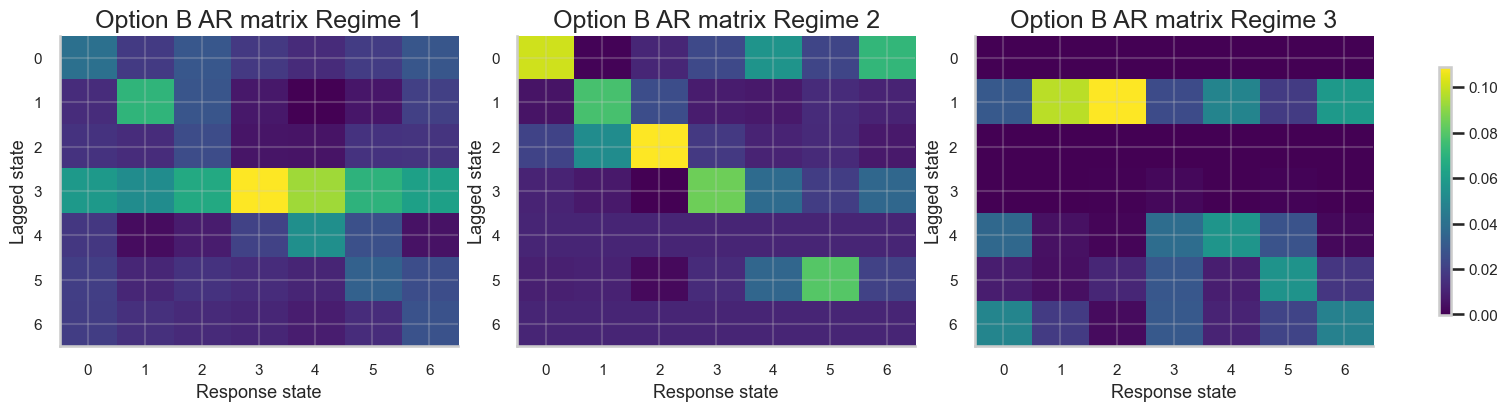

In [34]:
A_summary_B = summarize_A(A_B)
display(A_summary_B)
plot_A_heatmaps(A_B, title_prefix="Option B AR matrix", file_name=FIG_DIR / "fig_optionB_A_heatmaps_and_summary.png")

## 11. Covariate importance

,regime,mean_abs_covariate_effect
0,Regime 1,0.099666
1,Regime 2,0.108929
2,Regime 3,0.088969


Regime 1


,covariate,importance
0,occupancy_roll_state_3,0.559102
1,transition_roll_3_3,0.463995
2,occupancy_roll_state_4,0.437195
3,occupancy_roll_state_0,0.354135
4,transition_roll_4_4,0.344856
5,occupancy_roll_state_1,0.323923
6,transition_roll_0_0,0.291889
7,occupancy_roll_state_5,0.272784
8,occupancy_roll_state_6,0.261192
9,occupancy_roll_state_2,0.237018


Regime 2


,covariate,importance
0,occupancy_roll_state_2,0.603959
1,occupancy_roll_state_3,0.588958
2,occupancy_roll_state_0,0.587757
3,occupancy_roll_state_5,0.519798
4,transition_roll_3_3,0.482808
5,transition_roll_2_2,0.471310
6,transition_roll_0_0,0.449972
7,transition_roll_5_5,0.411557
8,occupancy_roll_state_1,0.318648
9,transition_roll_1_1,0.214111


Regime 3


,covariate,importance
0,occupancy_roll_state_4,0.638039
1,occupancy_roll_state_6,0.511555
2,transition_roll_4_4,0.501911
3,occupancy_roll_state_1,0.460059
4,occupancy_roll_state_5,0.341897
5,transition_roll_6_6,0.341150
6,transition_roll_1_1,0.307023
7,transition_roll_5_5,0.266499
8,occupancy_roll_state_2,0.111810
9,transition_roll_6_0,0.110076


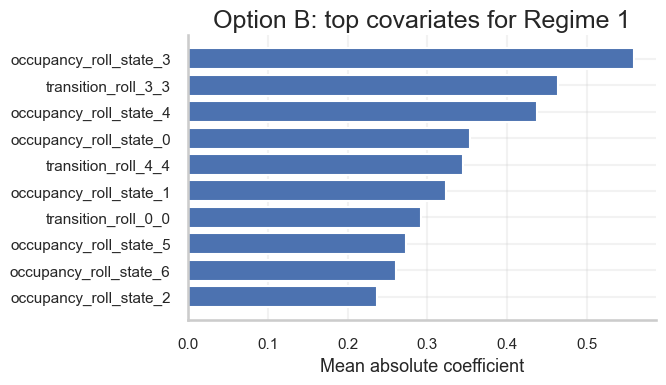

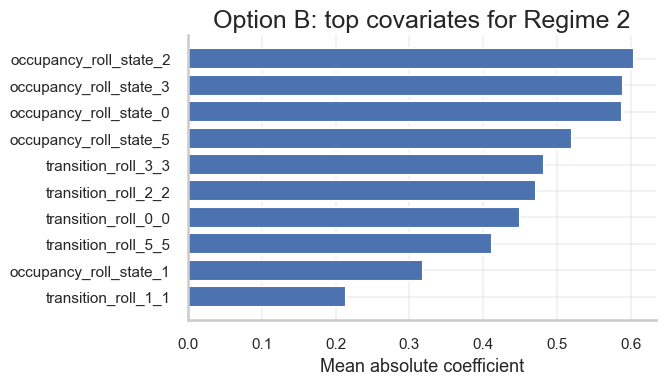

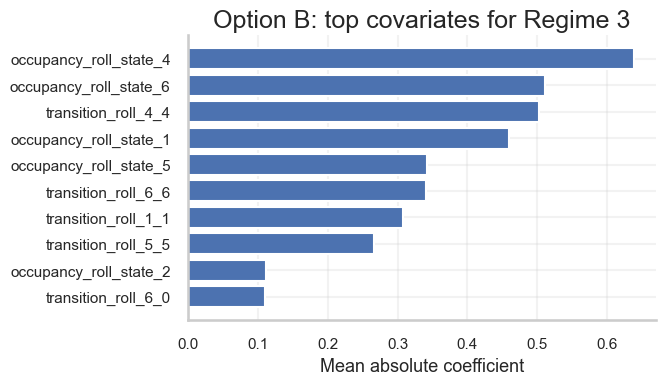

In [35]:
B_summary_B = summarize_B(B_B)
display(B_summary_B)

topB = top_covariates(B_B, feature_names_B, top_n=15)
for regime_name, df in topB.items():
    print(regime_name)
    display(df)

for k in range(B_B.shape[0]):
    imp = np.mean(np.abs(B_B[k]), axis=1)
    df_top = (
        pd.DataFrame({"covariate": np.asarray(feature_names_B).astype(str), "importance": imp})
        .sort_values("importance", ascending=False)
        .head(10)
        .sort_values("importance", ascending=True)
    )
    plt.figure(figsize=(7, 4.2))
    ax = plt.barh(df_top["covariate"], df_top["importance"])
    plt.title(f"Option B: top covariates for Regime {k+1}")
    plt.xlabel("Mean absolute coefficient")
    finish_plot()
    plt.savefig(FIG_DIR / f"fig_optionB_top_covariates_regime{k+1}.png")
    plt.show()


## 12. Prediction diagnostics

pred,0,1,2,3,4,5,6
true,,,,,,,
0,129533,223,5058,1947,12,787,0
1,2298,70894,2466,1090,211,187,282
2,7188,335,97193,1418,15,813,0
3,4235,182,1977,71589,34,519,0
4,2,1915,2,697,33152,45,79
5,2636,1375,1468,1363,71,53603,63
6,4,2187,0,341,71,25,32237


pred,0,1,2,3,4,5,6
true,,,,,,,
0,0.941647,0.001621,0.036769,0.014154,0.000087,0.005721,0.000000
1,0.029679,0.915612,0.031849,0.014078,0.002725,0.002415,0.003642
2,0.067201,0.003132,0.908668,0.013257,0.000140,0.007601,0.000000
3,0.053924,0.002317,0.025173,0.911544,0.000433,0.006608,0.000000
4,0.000056,0.053355,0.000056,0.019419,0.923660,0.001254,0.002201
5,0.043513,0.022698,0.024233,0.022500,0.001172,0.884845,0.001040
6,0.000115,0.062728,0.000000,0.009781,0.002036,0.000717,0.924624


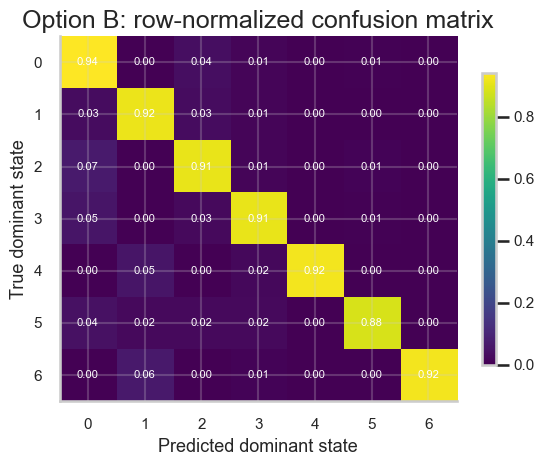

,state,recall
0,0,0.941647
1,1,0.915612
2,2,0.908668
3,3,0.911544
4,4,0.923660
5,5,0.884845
6,6,0.924624


In [36]:
conf_B, conf_row_B = confusion_from_probs(y_true_B, y_pred_B)
display(conf_B)
display(conf_row_B)

plot_confusion_heatmap(
    conf_row_B,
    title="Option B: row-normalized confusion matrix",
    file_name=FIG_DIR / "fig_optionB_confusion_matrix_and_recall.png"
)

state_recall_B = np.diag(conf_B.values) / conf_B.sum(axis=1).values
recall_df_B = pd.DataFrame({"state": conf_B.index, "recall": state_recall_B})
display(recall_df_B)


## 13. Unit-level heterogeneity

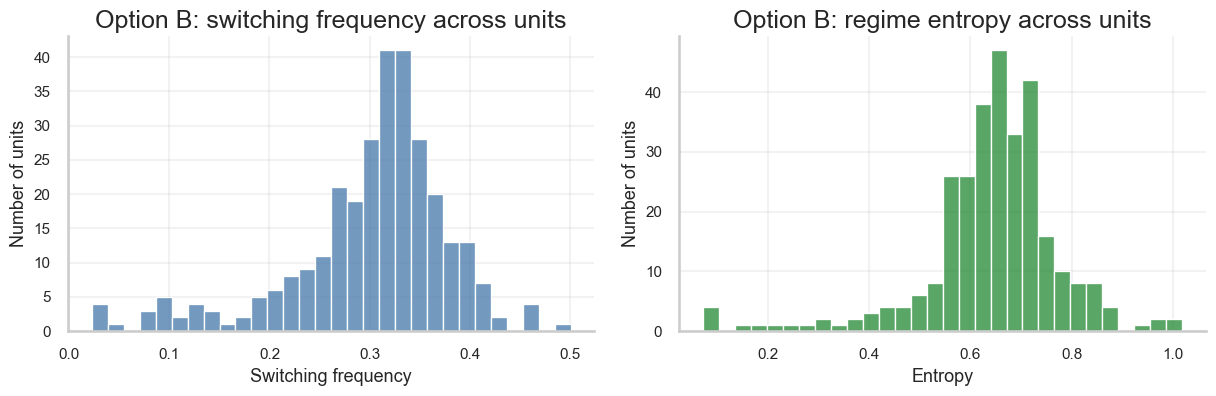

In [37]:
switch_rate_B = []
regime_entropy_B = []

for i in range(N_B):
    switches = np.sum(z_B[i, 1:] != z_B[i, :-1])
    switch_rate_B.append(switches / max(T_B - 1, 1))
    p_i = gamma_B[i].mean(axis=0)
    p_i = np.clip(p_i, 1e-12, None)
    p_i = p_i / p_i.sum()
    regime_entropy_B.append(-np.sum(p_i * np.log(p_i)))

switch_rate_B = np.array(switch_rate_B)
regime_entropy_B = np.array(regime_entropy_B)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
sns.histplot(switch_rate_B, bins=30, ax=axes[0], color="#4477AA", edgecolor="white")
axes[0].set_title("Option B: switching frequency across units")
axes[0].set_xlabel("Switching frequency")
axes[0].set_ylabel("Number of units")

sns.histplot(regime_entropy_B, bins=30, ax=axes[1], color="#228833", edgecolor="white")
axes[1].set_title("Option B: regime entropy across units")
axes[1].set_xlabel("Entropy")
axes[1].set_ylabel("Number of units")

plt.tight_layout()
sns.despine()
plt.savefig(FIG_DIR / "fig_optionB_switching_heterogeneity.png")
plt.show()


## 14. Regime–state interaction

,State 1,State 2,State 3,State 4,State 5,State 6,State 7
Regime 1,0.052,0.122,0.045,0.536,0.156,0.061,0.027
Regime 2,0.366,0.050,0.283,0.170,0.000,0.131,0.000
Regime 3,0.000,0.420,0.000,0.002,0.240,0.080,0.257


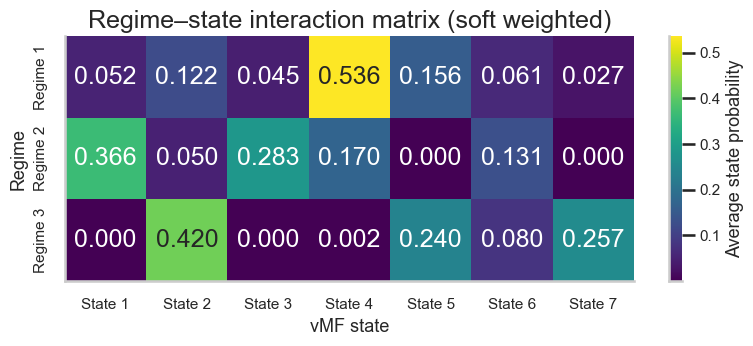

In [38]:
Y = y_true_B
regime_prob_flat = gamma_B.reshape(-1, gamma_B.shape[-1])

n_regimes = regime_prob_flat.shape[1]
n_states = Y.shape[1]
regime_state_soft = np.zeros((n_regimes, n_states))

for k in range(n_regimes):
    w = regime_prob_flat[:, k]
    regime_state_soft[k, :] = (w[:, None] * Y).sum(axis=0) / w.sum()

regime_state_soft_df = pd.DataFrame(
    regime_state_soft,
    index=[f"Regime {k+1}" for k in range(n_regimes)],
    columns=[f"State {j+1}" for j in range(n_states)]
)

regime_state_soft_df = regime_state_soft_df.div(regime_state_soft_df.sum(axis=1), axis=0)
display(regime_state_soft_df.round(3))

plt.figure(figsize=(8.2, 3.8))
sns.heatmap(
    regime_state_soft_df,
    cmap="viridis",
    annot=True,
    fmt=".3f",
    cbar_kws={"label": "Average state probability"}
)
plt.xlabel("vMF state")
plt.ylabel("Regime")
plt.title("Regime–state interaction matrix (soft weighted)")
finish_plot()
plt.savefig(FIG_DIR / "fig_regime_state_interaction_soft.png")
plt.show()


## 15. Regime shares by task

,regime_1_share,regime_2_share,regime_3_share
task_from_artifact,,,
DespicableMe,0.034,0.726,0.240
DiaryOfAWimpyKid,0.084,0.680,0.236
FunwithFractals,0.082,0.689,0.229
RestingState,0.039,0.687,0.274
ThePresent,0.030,0.707,0.264


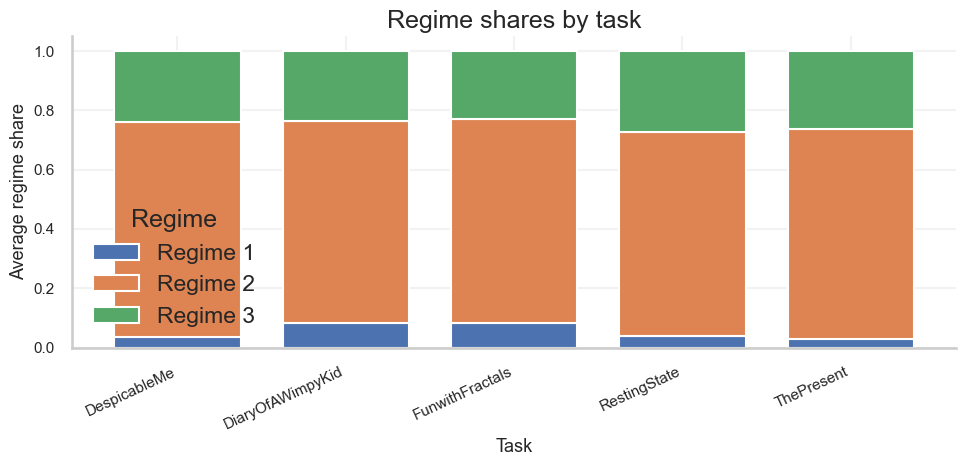

In [39]:
task_regime = (
    unit_df
    .groupby("task_from_artifact")[["regime_1_share", "regime_2_share", "regime_3_share"]]
    .mean()
    .sort_index()
)

display(task_regime.round(3))

ax = task_regime.plot(kind="bar", stacked=True, figsize=(10, 5), width=0.75)
ax.set_ylabel("Average regime share")
ax.set_xlabel("Task")
ax.set_title("Regime shares by task")
ax.legend(title="Regime", labels=["Regime 1", "Regime 2", "Regime 3"])
plt.xticks(rotation=25, ha="right")
finish_plot()
plt.savefig(FIG_DIR / "fig_regime_shares_by_task.png")
plt.show()


## 16. Subject-level associations

,Regime 1 share,Regime 2 share,Regime 3 share,Switching frequency
Age,-0.001,0.021,-0.021,0.001
Sex,-0.014,0.036,-0.021,0.034
Attention,-0.010,0.004,0.006,0.002
P-factor,-0.019,0.019,-0.000,-0.001


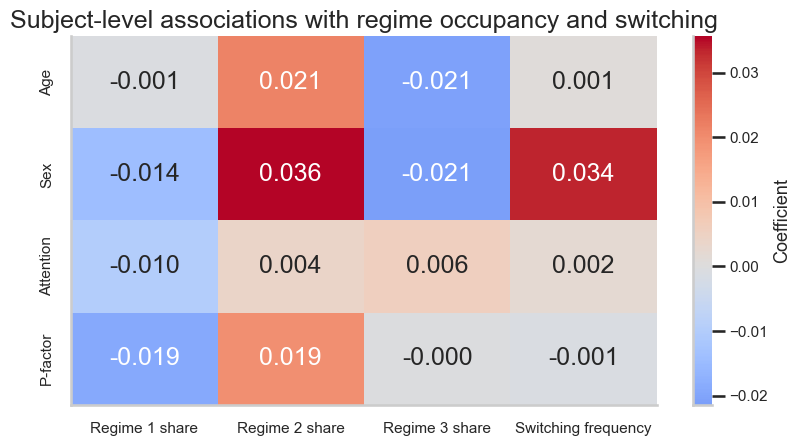

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

required_cols = [
    "age", "sex_num", "attention", "p_factor",
    "regime_1_share", "regime_2_share", "regime_3_share", "switch_freq"
]

missing_cols = [c for c in required_cols if c not in unit_df.columns]
if missing_cols:
    print("Cannot run subject-level association analysis. Missing columns:", missing_cols)
else:
    df_assoc = unit_df[required_cols].dropna().copy()

    continuous = ["age", "attention", "p_factor"]
    scaler = StandardScaler()
    df_assoc[[f"{c}_z" for c in continuous]] = scaler.fit_transform(df_assoc[continuous])

    predictors = ["age_z", "sex_num", "attention_z", "p_factor_z"]
    outcomes = ["regime_1_share", "regime_2_share", "regime_3_share", "switch_freq"]

    coef_mat = pd.DataFrame(
        index=["Age", "Sex", "Attention", "P-factor"],
        columns=["Regime 1 share", "Regime 2 share", "Regime 3 share", "Switching frequency"],
        dtype=float,
    )

    for out, out_label in zip(outcomes, coef_mat.columns):
        X = df_assoc[predictors].values
        y = df_assoc[out].values
        model = LinearRegression().fit(X, y)
        coef_mat[out_label] = model.coef_

    display(coef_mat.round(3))

    plt.figure(figsize=(8.2, 4.8))
    sns.heatmap(
        coef_mat,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        cbar_kws={"label": "Coefficient"}
    )
    plt.title("Subject-level associations with regime occupancy and switching")
    finish_plot()
    plt.savefig(FIG_DIR / "fig_subject_associations_regimes.png")
    plt.show()


## 17. Final summary

In [41]:
takeaway = pd.DataFrame([
    {"Finding": "Best-performing model", "Conclusion": "Option B: unit-specific switching PVAR"},
    {"Finding": "Main structural insight", "Conclusion": "Regime timing is heterogeneous across units"},
    {"Finding": "Global vs unit-specific", "Conclusion": "Unit-specific switching outperforms common-regime switching"},
    {"Finding": "Latent compression", "Conclusion": "SLDS-style latent compression does not outperform direct switching in the 7-state space"},
])
display(takeaway)


,Finding,Conclusion
0,Best-performing model,Option B: unit-specific switching PVAR
1,Main structural insight,Regime timing is heterogeneous across units
2,Global vs unit-specific,Unit-specific switching outperforms common-reg...
3,Latent compression,SLDS-style latent compression does not outperf...
